In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
"""
=============================================================
STEP 2 : Motion Pattern Extraction + KDE Abnormal Point Detection
=============================================================
Based on: "A framework for ship abnormal behaviour detection
           and classification using AIS data" (Rong et al., 2024)

Pipeline:
  1. Load reduced dataset
  2. Per-ship: compute lateral distance to route centreline
  3. Build normalcy model (KDE on SOG, COG, lateral distance)
  4. Flag abnormal points where KDE density < threshold
  5. Save flagged dataset for Sliding Window (Step 3)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KernelDensity
from scipy.spatial    import cKDTree

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH   = "/content/drive/MyDrive/AIS_reduced/ais_reduced_130ships_156930rows.csv"
OUTPUT_DIR   = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# KDE threshold percentile:
# Points below this percentile of density → flagged as abnormal
# Paper uses low-probability → anomaly. 15th percentile is a good start.
KDE_THRESHOLD_PERCENTILE = 15

# Minimum segment length to be considered a valid abnormal behaviour
MIN_SEGMENT_POINTS = 3

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def haversine(lat1, lon1, lat2, lon2):
    """
    Vectorised Haversine distance in km.
    Inputs can be scalars or numpy arrays.
    """
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def compute_route_centreline(lats, lons, n_points=50):
    """
    Estimate route centreline by dividing the bounding box into
    n_points segments and taking the median lat/lon in each bin.
    This is a simplified version of the DTW-based centreline in the paper.
    Works well for single-ship trajectories.
    """
    # Use cumulative distance as the parameter
    dists = np.zeros(len(lats))
    for i in range(1, len(lats)):
        dists[i] = dists[i-1] + haversine(lats[i-1], lons[i-1], lats[i], lons[i])

    total = dists[-1]
    if total < 0.01:   # ship barely moved
        return np.array([lats[0]]), np.array([lons[0]])

    bins  = np.linspace(0, total, n_points + 1)
    cl_lats, cl_lons = [], []

    for j in range(n_points):
        mask = (dists >= bins[j]) & (dists < bins[j+1])
        if mask.sum() > 0:
            cl_lats.append(np.median(lats[mask]))
            cl_lons.append(np.median(lons[mask]))

    if len(cl_lats) == 0:
        return np.array([lats[0]]), np.array([lons[0]])

    return np.array(cl_lats), np.array(cl_lons)


def lateral_distance_to_centreline(ship_lats, ship_lons, cl_lats, cl_lons):
    """
    For each ship position, find the nearest centreline point
    and return the distance (km). This approximates the perpendicular
    lateral distance described in Eq.(4) of the paper.
    """
    # Build KD-tree on centreline points (use lat/lon directly as proxy)
    # For small areas this is acceptable; for large areas convert to XYZ.
    cl_pts = np.column_stack([cl_lats, cl_lons])
    ship_pts = np.column_stack([ship_lats, ship_lons])

    tree = cKDTree(cl_pts)
    dists_deg, idxs = tree.query(ship_pts, k=1)

    # Convert degree-distance to km (approximate: 1° ≈ 111 km)
    dists_km = dists_deg * 111.0
    return dists_km


def fit_kde(values, bandwidth=None):
    """
    Fit a 1-D Kernel Density Estimator.
    Returns the fitted KDE object.
    Bandwidth selected by Silverman's rule if not specified.
    """
    v = values.reshape(-1, 1)
    if bandwidth is None:
        # Silverman's rule of thumb
        n  = len(values)
        sd = np.std(values)
        bandwidth = 1.06 * sd * n**(-0.2) if sd > 0 else 0.1
        bandwidth = max(bandwidth, 0.01)   # safety floor

    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
    kde.fit(v)
    return kde


def score_kde(kde, values):
    """Return probability densities (not log) for given values."""
    log_dens = kde.score_samples(values.reshape(-1, 1))
    return np.exp(log_dens)


# ─────────────────────────────────────────────────────────────
# STEP 1 : Load data
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading reduced dataset...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Per-ship KDE abnormal point detection
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Running KDE abnormal point detection per ship...")
print("=" * 60)
print(f"  KDE threshold     : {KDE_THRESHOLD_PERCENTILE}th percentile")
print(f"  Min segment pts   : {MIN_SEGMENT_POINTS}")
print()

all_results   = []
ship_summaries = []
ships = df['MMSI'].unique()
total = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total} (MMSI={mmsi})...", end='\r')

    grp = df[df['MMSI'] == mmsi].copy().reset_index(drop=True)
    n   = len(grp)

    lats = grp['LAT'].values
    lons = grp['LON'].values
    sog  = grp['SOG'].values
    cog  = grp['COG'].values
    t    = grp['BaseDateTime'].values

    # ── 2a. Compute route centreline ──────────────────────────
    cl_lats, cl_lons = compute_route_centreline(lats, lons, n_points=50)

    # ── 2b. Compute lateral distance to centreline ────────────
    lat_dist = lateral_distance_to_centreline(lats, lons, cl_lats, cl_lons)
    grp['lateral_dist'] = lat_dist

    # ── 2c. Normalise lateral distance to route width ─────────
    route_width = np.percentile(lat_dist, 95)   # 95th pct as route boundary
    route_width = max(route_width, 0.01)
    grp['lateral_dist_norm'] = lat_dist / route_width

    # ── 2d. Fit KDE on SOG, COG, lateral_dist ─────────────────
    # Use interior points only (exclude first/last — paper Section 2.4)
    interior = slice(1, n-1)

    kde_sog = fit_kde(sog[interior])
    kde_cog = fit_kde(cog[interior])
    kde_lat = fit_kde(lat_dist[interior])

    # ── 2e. Score all interior points ─────────────────────────
    dens_sog = score_kde(kde_sog, sog[interior])
    dens_cog = score_kde(kde_cog, cog[interior])
    dens_lat = score_kde(kde_lat, lat_dist[interior])

    # ── 2f. Determine thresholds (KDE_THRESHOLD_PERCENTILE) ───
    thr_sog = np.percentile(dens_sog, KDE_THRESHOLD_PERCENTILE)
    thr_cog = np.percentile(dens_cog, KDE_THRESHOLD_PERCENTILE)
    thr_lat = np.percentile(dens_lat, KDE_THRESHOLD_PERCENTILE)

    # ── 2g. Flag abnormal points ───────────────────────────────
    # A point is abnormal if ANY of the three densities fall below threshold
    # (paper Algorithm 1, lines 7-12)
    ab_sog = dens_sog < thr_sog
    ab_cog = dens_cog < thr_cog
    ab_lat = dens_lat < thr_lat
    ab_any = ab_sog | ab_cog | ab_lat

    # Build full-length flag array (first and last points = False)
    full_flag = np.zeros(n, dtype=bool)
    full_flag[1:n-1] = ab_any

    grp['ab_sog']      = False
    grp['ab_cog']      = False
    grp['ab_lat']      = False
    grp['ab_any']      = False
    grp.loc[grp.index[1:n-1], 'ab_sog'] = ab_sog
    grp.loc[grp.index[1:n-1], 'ab_cog'] = ab_cog
    grp.loc[grp.index[1:n-1], 'ab_lat'] = ab_lat
    grp.loc[grp.index[1:n-1], 'ab_any'] = ab_any

    # Store densities for analysis
    dens_sog_full = np.full(n, np.nan)
    dens_cog_full = np.full(n, np.nan)
    dens_lat_full = np.full(n, np.nan)
    dens_sog_full[1:n-1] = dens_sog
    dens_cog_full[1:n-1] = dens_cog
    dens_lat_full[1:n-1] = dens_lat
    grp['dens_sog'] = dens_sog_full
    grp['dens_cog'] = dens_cog_full
    grp['dens_lat'] = dens_lat_full

    all_results.append(grp)

    # Summary stats
    ship_summaries.append({
        'MMSI'           : mmsi,
        'n_records'      : n,
        'n_ab_points'    : int(ab_any.sum()),
        'pct_ab'         : round(ab_any.mean() * 100, 1),
        'ab_sog_pts'     : int(ab_sog.sum()),
        'ab_cog_pts'     : int(ab_cog.sum()),
        'ab_lat_pts'     : int(ab_lat.sum()),
        'route_width_km' : round(route_width, 3),
    })

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3 : Combine results
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Combining results...")
print("=" * 60)

df_out = pd.concat(all_results, ignore_index=True)
summary_df = pd.DataFrame(ship_summaries)

total_ab_pts = summary_df['n_ab_points'].sum()
total_pts    = summary_df['n_records'].sum()
print(f"  Total points       : {total_pts:,}")
print(f"  Total abnormal pts : {total_ab_pts:,} ({total_ab_pts/total_pts*100:.1f}%)")
print(f"  Ships with >0 ab   : {(summary_df['n_ab_points'] > 0).sum()}")
print(f"\n  Top 10 ships by abnormal point count:")
print(summary_df.sort_values('n_ab_points', ascending=False).head(10)
      [['MMSI','n_records','n_ab_points','pct_ab','ab_sog_pts','ab_cog_pts','ab_lat_pts']]
      .to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 4 : Save outputs
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Saving outputs...")
print("=" * 60)

# Main flagged dataset
out_main = os.path.join(OUTPUT_DIR, "ais_kde_flagged.csv")
df_out.to_csv(out_main, index=False)
size_mb = os.path.getsize(out_main) / (1024**2)
print(f"  KDE-flagged data   : {out_main}  ({size_mb:.1f} MB)")

# Ship summary
out_summ = os.path.join(OUTPUT_DIR, "kde_ship_summary.csv")
summary_df.sort_values('n_ab_points', ascending=False).to_csv(out_summ, index=False)
print(f"  Ship summary       : {out_summ}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Ships processed    : {total}")
print(f"  Total records      : {total_pts:,}")
print(f"  Abnormal points    : {total_ab_pts:,} ({total_ab_pts/total_pts*100:.1f}%)")
print(f"  KDE threshold      : {KDE_THRESHOLD_PERCENTILE}th percentile")
print(f"\n  Columns added to dataset:")
print(f"    lateral_dist      : perpendicular distance to route centreline (km)")
print(f"    lateral_dist_norm : normalised by route width")
print(f"    ab_sog            : True if SOG density < threshold")
print(f"    ab_cog            : True if COG density < threshold")
print(f"    ab_lat            : True if lateral density < threshold")
print(f"    ab_any            : True if any of the above (= abnormal point)")
print(f"    dens_sog/cog/lat  : raw KDE density values")
print(f"\n  Next step: Load '{out_main}'")
print(f"             for Sliding Window aggregation (Step 3)")
print("=" * 60)

STEP 1: Loading reduced dataset...
  Loaded : 156,930 rows | 130 ships | 1.1s

STEP 2: Running KDE abnormal point detection per ship...
  KDE threshold     : 15th percentile
  Min segment pts   : 3


  Done: 130 ships processed.

STEP 3: Combining results...
  Total points       : 156,930
  Total abnormal pts : 46,242 (29.5%)
  Ships with >0 ab   : 130

  Top 10 ships by abnormal point count:
     MMSI  n_records  n_ab_points  pct_ab  ab_sog_pts  ab_cog_pts  ab_lat_pts
316003289       1273          500    39.3         185         191         191
316001232       1254          481    38.4         180         188         188
316003656       1214          478    39.4         174         182         182
316011407       1252          475    38.0         185         188         188
316011409       1286          465    36.2         183         173         193
366978710       1242          465    37.5         173         185         152
367594510       1241          465    37.5         184     

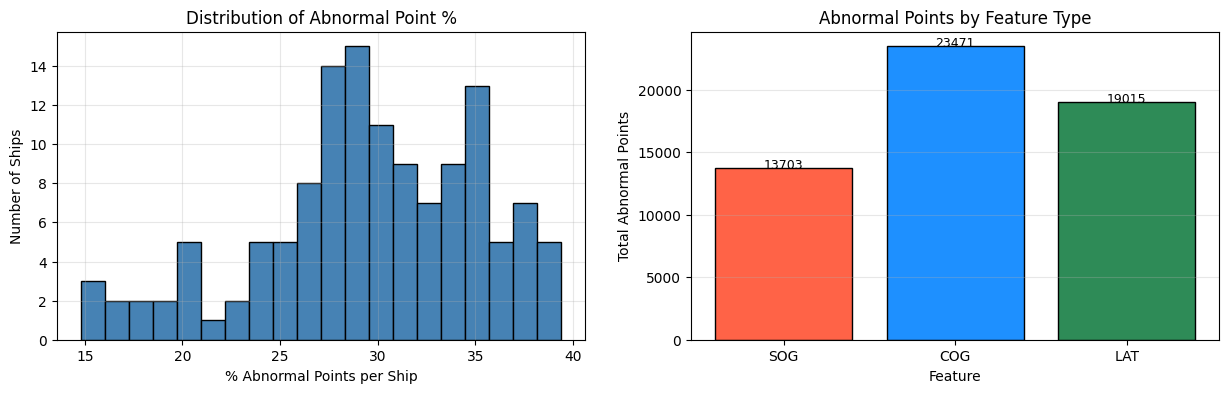

In [ ]:
# ─────────────────────────────────────────────────────────────
# OPTIONAL: Inline plots for Step 2
# ─────────────────────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot 1: % abnormal points per ship
pct_vals = summary_df['pct_ab'].values
axes[0].hist(pct_vals, bins=20, color='steelblue', edgecolor='k')
axes[0].set_xlabel('% Abnormal Points per Ship')
axes[0].set_ylabel('Number of Ships')
axes[0].set_title('Distribution of Abnormal Point %')
axes[0].grid(alpha=0.3)

# Plot 2: Breakdown — SOG vs COG vs LAT abnormal points
breakdown = summary_df[['ab_sog_pts','ab_cog_pts','ab_lat_pts']].sum()
axes[1].bar(['SOG','COG','LAT'], breakdown.values,
            color=['tomato','dodgerblue','seagreen'], edgecolor='k')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Total Abnormal Points')
axes[1].set_title('Abnormal Points by Feature Type')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(breakdown.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)



STEP 1: Loading reduced dataset...
  Loaded : 156,930 rows | 130 ships | 0.4s

STEP 2: Mahalanobis outlier detection per ship...
  Chi2 percentile   : 95th
  Features used     : [SOG, COG, lateral_dist_km]
  Method            : Minimum Covariance Determinant (robust)


  Done: 130 ships processed.

STEP 3: Combining results...
  Total points       : 156,930
  Total abnormal pts : 24,954 (15.9%)
  Ships with >0 ab   : 123
  Mean Mahal dist    : 34.956
  Mean threshold     : 2.795

  Top 10 ships by abnormal point count:
     MMSI  n_records  n_ab_points  pct_ab  mahal_max  mahal_thr
367370010       1285          449    35.0     46.054      2.795
366991740       1266          444    35.1    200.775      2.795
366979030       1267          421    33.3     16.871      2.795
367594510       1241          414    33.4     35.979      2.795
366995760       1256          406    32.4     26.917      2.795
367372810       1209          402    33.3     64.827      2.795
367330510       1297       

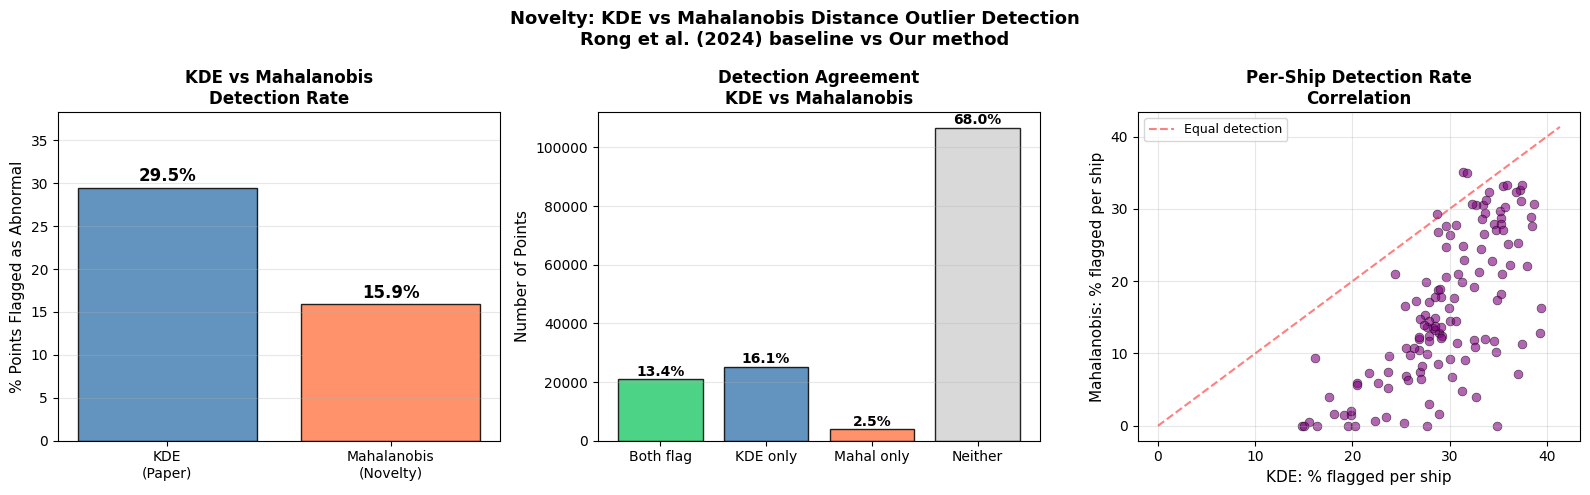

  ↑ Comparison plot displayed

STEP 5: Visualising Mahalanobis detection for sample ships...


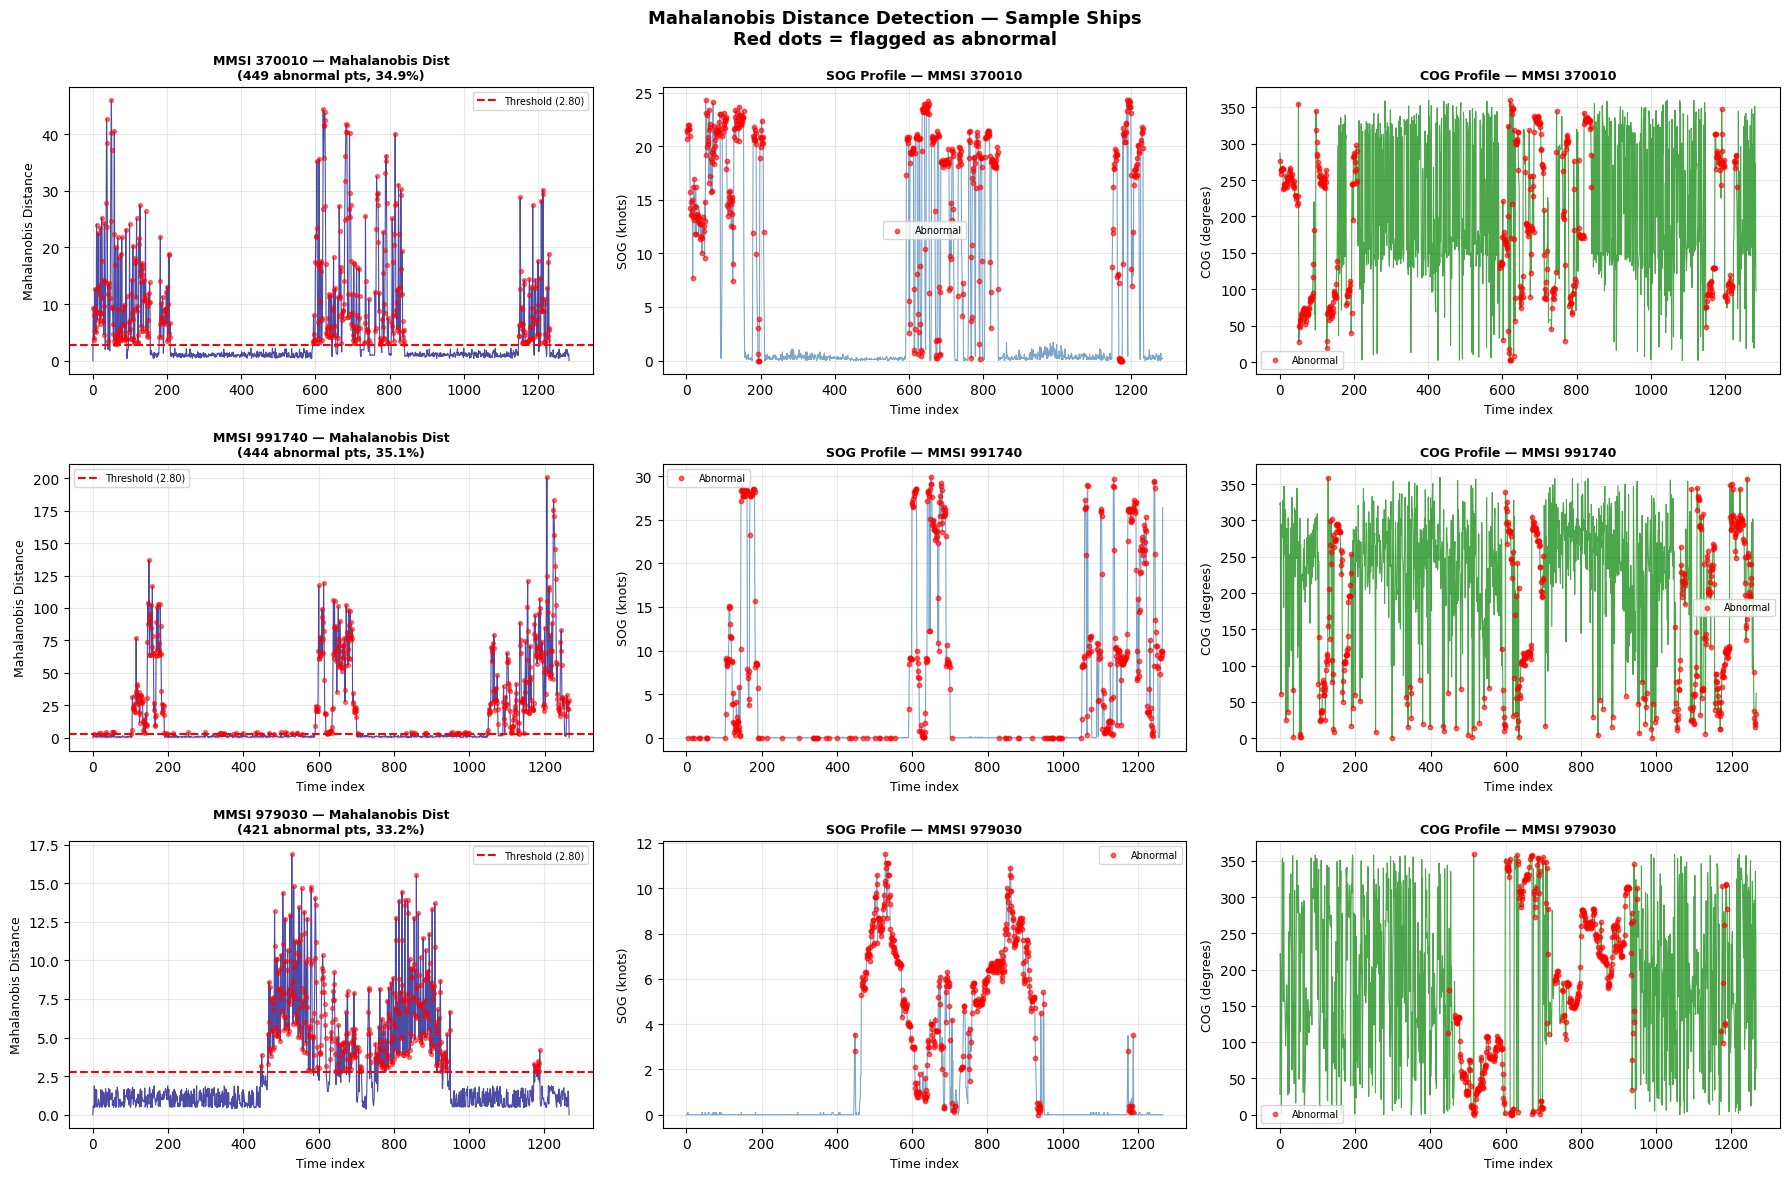

  ↑ Sample ship profiles displayed


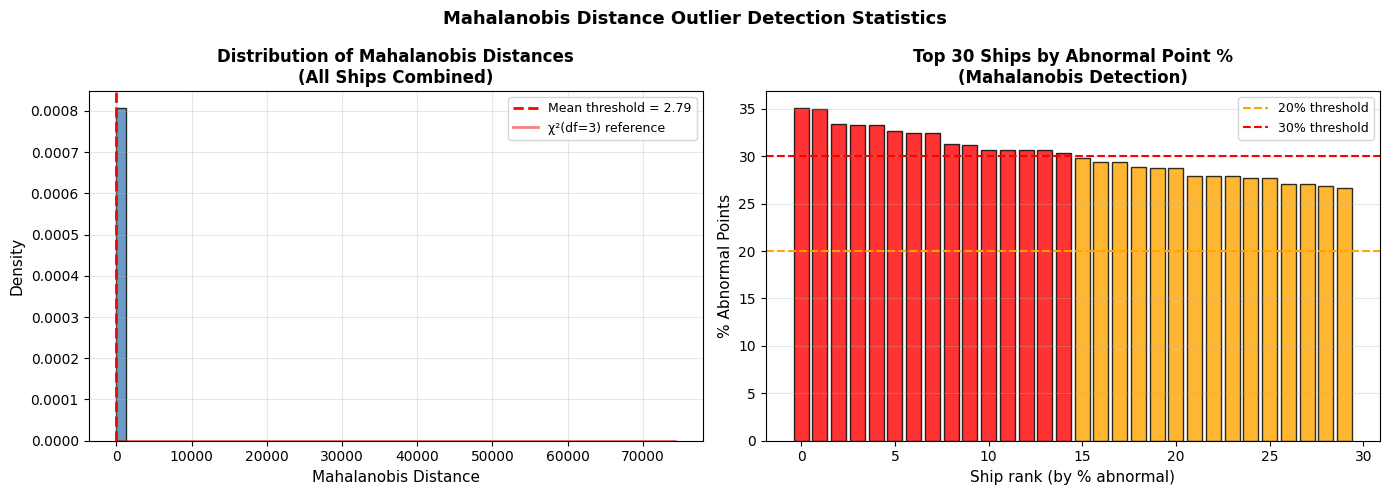

  ↑ Distance distribution plots displayed

STEP 7: Saving outputs...
  Mahal-flagged data : /content/drive/MyDrive/AIS_reduced/ais_mahal_flagged.csv  (31.7 MB)
  Ship summary       : /content/drive/MyDrive/AIS_reduced/mahal_ship_summary.csv

FINAL SUMMARY
  Method            : Mahalanobis Distance (MCD robust estimator)
  Chi2 threshold    : 95th percentile (df=3)
  Ships processed   : 130
  Total points      : 156,930
  Abnormal points   : 24,954 (15.9%)

  Advantages over KDE (paper method):
    ✅ Multivariate — captures SOG+COG+Lateral correlations
    ✅ Robust MCD estimator — resistant to masking effect
    ✅ Theoretically grounded (chi-squared threshold)
    ✅ Scale-invariant — no normalisation needed
    ✅ Single unified threshold for all 3 features

  Output file: '/content/drive/MyDrive/AIS_reduced/ais_mahal_flagged.csv'
  → Use this as input to Step 3 (Sliding Window)
    Change INPUT_PATH in Step 3 to: '/content/drive/MyDrive/AIS_reduced/ais_mahal_flagged.csv'

  Columns adde

In [ ]:
"""
=============================================================
NOVELTY: Mahalanobis Distance Outlier Detection
         (Replaces KDE-based detection from Step 2)
=============================================================
Paper method  : KDE per feature independently (univariate)
Our method    : Mahalanobis distance (multivariate)

Why Mahalanobis is better:
  - KDE checks SOG, COG, lateral distance INDEPENDENTLY
  - Mahalanobis captures CORRELATIONS between all 3 features
  - E.g., low SOG + high COG change + off-route TOGETHER
    is more abnormal than each alone
  - More sensitive to combined multi-feature anomalies
  - Naturally scale-invariant (no normalisation needed)

Method:
  For each ship route, compute mean vector μ and
  covariance matrix Σ of [SOG, COG, lateral_dist].
  Mahalanobis distance D = sqrt((x-μ)ᵀ Σ⁻¹ (x-μ))
  Points with D > threshold (chi2 95th percentile) → abnormal

Output: Same format as ais_kde_flagged.csv
        → can feed directly into Step 3 (Sliding Window)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import mahalanobis
from scipy.stats            import chi2
from scipy.spatial          import cKDTree

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH = "/content/drive/MyDrive/AIS_reduced/ais_reduced_130ships_156930rows.csv"
OUTPUT_DIR = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Chi-squared threshold for Mahalanobis:
# df=3 features, 95th percentile → points beyond this = abnormal
# Increase to 97.5 or 99 to reduce false positives
CHI2_PERCENTILE   = 95    # paper equivalent of KDE threshold
MIN_SEGMENT_POINTS = 3    # minimum points for covariance estimation

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────

def compute_route_centreline(lats, lons, n_points=50):
    """Estimate route centreline by binning cumulative distance."""
    dists = np.zeros(len(lats))
    for i in range(1, len(lats)):
        dlat = np.radians(lats[i]-lats[i-1])
        dlon = np.radians(lons[i]-lons[i-1])
        a    = (np.sin(dlat/2)**2 +
                np.cos(np.radians(lats[i-1])) *
                np.cos(np.radians(lats[i])) *
                np.sin(dlon/2)**2)
        dists[i] = dists[i-1] + 2*6371*np.arcsin(np.sqrt(np.clip(a,0,1)))

    total = dists[-1]
    if total < 0.01:
        return np.array([lats[0]]), np.array([lons[0]])

    bins    = np.linspace(0, total, n_points+1)
    cl_lats, cl_lons = [], []
    for j in range(n_points):
        mask = (dists >= bins[j]) & (dists < bins[j+1])
        if mask.sum() > 0:
            cl_lats.append(np.median(lats[mask]))
            cl_lons.append(np.median(lons[mask]))

    return (np.array(cl_lats) if cl_lats else np.array([lats[0]]),
            np.array(cl_lons) if cl_lons else np.array([lons[0]]))


def lateral_dist_km(ship_lats, ship_lons, cl_lats, cl_lons):
    """Nearest-centreline perpendicular distance in km."""
    cl_pts   = np.column_stack([cl_lats, cl_lons])
    ship_pts = np.column_stack([ship_lats, ship_lons])
    tree     = cKDTree(cl_pts)
    dists_deg, _ = tree.query(ship_pts, k=1)
    return dists_deg * 111.0


def wrap_cog(cog):
    """Wrap COG to [0, 360)."""
    return cog % 360


def mahalanobis_outliers(features, chi2_pct=95):
    """
    Compute Mahalanobis distance for each point.
    features : (n, d) array — columns = [SOG, COG, lateral_dist]
    Returns  : (distances, threshold, is_outlier mask)

    Uses robust covariance via Minimum Covariance Determinant
    if sklearn available, else standard covariance.
    """
    n, d = features.shape
    if n < d + 2:
        # Too few points — fall back to z-score per feature
        zscores  = np.abs((features - features.mean(axis=0)) /
                          (features.std(axis=0) + 1e-9))
        dists    = zscores.max(axis=1)
        threshold = 2.5
        return dists, threshold, dists > threshold

    # Try robust covariance (less sensitive to outliers in training)
    try:
        from sklearn.covariance import MinCovDet
        mcd   = MinCovDet(random_state=42, support_fraction=0.85)
        mcd.fit(features)
        mu    = mcd.location_
        cov   = mcd.covariance_
    except Exception:
        mu  = features.mean(axis=0)
        cov = np.cov(features.T)

    # Pseudo-inverse for numerical stability
    try:
        cov_inv = np.linalg.pinv(cov)
    except Exception:
        cov_inv = np.linalg.inv(cov + np.eye(d)*1e-6)

    # Compute D² = (x - μ)ᵀ Σ⁻¹ (x - μ)
    diff  = features - mu
    d2    = np.array([diff[i] @ cov_inv @ diff[i] for i in range(n)])
    dists = np.sqrt(np.clip(d2, 0, None))

    # Chi-squared threshold: D² ~ χ²(df=d)
    threshold = np.sqrt(chi2.ppf(chi2_pct/100, df=d))

    return dists, threshold, dists > threshold


# ─────────────────────────────────────────────────────────────
# STEP 1: Load data
# ─────────────────────────────────────────────────────────────
print("="*60)
print("STEP 1: Loading reduced dataset...")
print("="*60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI','BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique()} ships | {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────────────────────
# STEP 2: Per-ship Mahalanobis detection
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 2: Mahalanobis outlier detection per ship...")
print("="*60)
print(f"  Chi2 percentile   : {CHI2_PERCENTILE}th")
print(f"  Features used     : [SOG, COG, lateral_dist_km]")
print(f"  Method            : Minimum Covariance Determinant (robust)")
print()

all_results    = []
ship_summaries = []
ships          = df['MMSI'].unique()
total          = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total} (MMSI={mmsi})...", end='\r')

    grp = df[df['MMSI']==mmsi].copy().reset_index(drop=True)
    n   = len(grp)

    lats = grp['LAT'].values
    lons = grp['LON'].values
    sog  = grp['SOG'].values
    cog  = grp['COG'].values

    # ── Centreline & lateral distance ────────────────────────
    cl_lats, cl_lons = compute_route_centreline(lats, lons, n_points=50)
    lat_dist         = lateral_dist_km(lats, lons, cl_lats, cl_lons)

    route_width = np.percentile(lat_dist, 95)
    route_width = max(route_width, 0.01)
    lat_norm    = lat_dist / route_width

    grp['lateral_dist']      = lat_dist
    grp['lateral_dist_norm'] = lat_norm

    # ── Build feature matrix for interior points ─────────────
    # Use indices 1 to n-2 (interior, same as paper Algorithm 1)
    interior = slice(1, n-1)
    feat_mat = np.column_stack([
        sog[interior],       # Speed Over Ground (knots)
        cog[interior],       # Course Over Ground (degrees)
        lat_dist[interior],  # Lateral distance (km)
    ])

    # ── Mahalanobis distance ──────────────────────────────────
    m_dists, threshold, ab_mask = mahalanobis_outliers(
        feat_mat, chi2_pct=CHI2_PERCENTILE
    )

    # Decompose which feature drives the anomaly
    # (compare standardised individual deviations)
    mu_int  = feat_mat.mean(axis=0)
    std_int = feat_mat.std(axis=0) + 1e-9
    z_mat   = np.abs((feat_mat - mu_int) / std_int)
    ab_sog  = (z_mat[:,0] > 2.0) & ab_mask
    ab_cog  = (z_mat[:,1] > 2.0) & ab_mask
    ab_lat  = (z_mat[:,2] > 2.0) & ab_mask

    # Build full-length arrays
    full_dist = np.full(n, 0.0)
    full_flag = np.zeros(n, dtype=bool)
    full_sog  = np.zeros(n, dtype=bool)
    full_cog  = np.zeros(n, dtype=bool)
    full_lat  = np.zeros(n, dtype=bool)

    full_dist[1:n-1] = m_dists
    full_flag[1:n-1] = ab_mask
    full_sog[1:n-1]  = ab_sog
    full_cog[1:n-1]  = ab_cog
    full_lat[1:n-1]  = ab_lat

    grp['mahal_dist']  = full_dist
    grp['mahal_thr']   = threshold
    grp['ab_any']      = full_flag
    grp['ab_sog']      = full_sog
    grp['ab_cog']      = full_cog
    grp['ab_lat']      = full_lat

    # KDE-style density columns (set to NaN — replaced by Mahalanobis)
    grp['dens_sog'] = np.where(full_flag, np.nan, 1.0)
    grp['dens_cog'] = np.where(full_flag, np.nan, 1.0)
    grp['dens_lat'] = np.where(full_flag, np.nan, 1.0)

    all_results.append(grp)

    ship_summaries.append({
        'MMSI'         : mmsi,
        'n_records'    : n,
        'n_ab_points'  : int(ab_mask.sum()),
        'pct_ab'       : round(ab_mask.mean()*100, 1),
        'mahal_thr'    : round(float(threshold), 3),
        'mahal_max'    : round(float(m_dists.max()), 3),
        'mahal_mean'   : round(float(m_dists.mean()), 3),
        'ab_sog_pts'   : int(ab_sog.sum()),
        'ab_cog_pts'   : int(ab_cog.sum()),
        'ab_lat_pts'   : int(ab_lat.sum()),
        'route_width_km': round(route_width, 3),
    })

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3: Combine results
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 3: Combining results...")
print("="*60)

df_out     = pd.concat(all_results, ignore_index=True)
summary_df = pd.DataFrame(ship_summaries)

total_ab  = summary_df['n_ab_points'].sum()
total_pts = summary_df['n_records'].sum()
print(f"  Total points       : {total_pts:,}")
print(f"  Total abnormal pts : {total_ab:,} ({total_ab/total_pts*100:.1f}%)")
print(f"  Ships with >0 ab   : {(summary_df['n_ab_points']>0).sum()}")
print(f"  Mean Mahal dist    : {summary_df['mahal_mean'].mean():.3f}")
print(f"  Mean threshold     : {summary_df['mahal_thr'].mean():.3f}")

print(f"\n  Top 10 ships by abnormal point count:")
print(summary_df.sort_values('n_ab_points', ascending=False)
      .head(10)[['MMSI','n_records','n_ab_points','pct_ab',
                  'mahal_max','mahal_thr']].to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 4: Compare KDE vs Mahalanobis (if KDE file exists)
# ─────────────────────────────────────────────────────────────
kde_path = "/content/drive/MyDrive/AIS_reduced/ais_kde_flagged.csv"
comparison_possible = os.path.exists(kde_path)

if comparison_possible:
    print("\n"+"="*60)
    print("STEP 4: Comparing KDE vs Mahalanobis detection...")
    print("="*60)
    kde_df = pd.read_csv(kde_path)

    kde_ab_pct   = kde_df['ab_any'].mean() * 100
    mahal_ab_pct = df_out['ab_any'].mean() * 100

    # Agreement analysis
    merged = df_out[['MMSI','BaseDateTime','ab_any']].copy()
    merged.columns = ['MMSI','BaseDateTime','mahal_ab']
    merged['kde_ab'] = kde_df['ab_any'].values

    both_flag  = (merged['mahal_ab'] & merged['kde_ab']).sum()
    only_kde   = (~merged['mahal_ab'] & merged['kde_ab']).sum()
    only_mahal = (merged['mahal_ab'] & ~merged['kde_ab']).sum()
    neither    = (~merged['mahal_ab'] & ~merged['kde_ab']).sum()

    print(f"  KDE   flagged      : {kde_ab_pct:.1f}% of points")
    print(f"  Mahal flagged      : {mahal_ab_pct:.1f}% of points")
    print(f"\n  Agreement breakdown:")
    print(f"    Both flag same point : {both_flag:,} ({both_flag/len(merged)*100:.1f}%)")
    print(f"    Only KDE flags       : {only_kde:,} ({only_kde/len(merged)*100:.1f}%)")
    print(f"    Only Mahal flags     : {only_mahal:,} ({only_mahal/len(merged)*100:.1f}%)")
    print(f"    Neither flags        : {neither:,} ({neither/len(merged)*100:.1f}%)")

    # Venn diagram style comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Bar comparison
    ax = axes[0]
    methods = ['KDE\n(Paper)', 'Mahalanobis\n(Novelty)']
    pcts    = [kde_ab_pct, mahal_ab_pct]
    colors  = ['steelblue','coral']
    bars    = ax.bar(methods, pcts, color=colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, pcts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=12, fontweight='bold')
    ax.set_ylabel('% Points Flagged as Abnormal', fontsize=11)
    ax.set_title('KDE vs Mahalanobis\nDetection Rate', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(pcts)*1.3)

    # Agreement breakdown
    ax = axes[1]
    labels  = ['Both flag', 'KDE only', 'Mahal only', 'Neither']
    values  = [both_flag, only_kde, only_mahal, neither]
    colors2 = ['#2ecc71','steelblue','coral','lightgrey']
    bars2   = ax.bar(labels, values, color=colors2,
                     edgecolor='black', alpha=0.85)
    for bar, val in zip(bars2, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{val/len(merged)*100:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_ylabel('Number of Points', fontsize=11)
    ax.set_title('Detection Agreement\nKDE vs Mahalanobis', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Per-ship comparison
    ax = axes[2]
    kde_per_ship   = kde_df.groupby('MMSI')['ab_any'].mean()*100
    mahal_per_ship = df_out.groupby('MMSI')['ab_any'].mean()*100
    common_ships   = kde_per_ship.index.intersection(mahal_per_ship.index)
    ax.scatter(kde_per_ship[common_ships], mahal_per_ship[common_ships],
               alpha=0.6, color='purple', s=40, edgecolors='black', linewidth=0.5)
    lim_max = max(kde_per_ship.max(), mahal_per_ship.max()) * 1.05
    ax.plot([0, lim_max],[0, lim_max], 'r--', alpha=0.5, label='Equal detection')
    ax.set_xlabel('KDE: % flagged per ship', fontsize=11)
    ax.set_ylabel('Mahalanobis: % flagged per ship', fontsize=11)
    ax.set_title('Per-Ship Detection Rate\nCorrelation', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.suptitle('Novelty: KDE vs Mahalanobis Distance Outlier Detection\n'
                 'Rong et al. (2024) baseline vs Our method',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ↑ Comparison plot displayed")

# ─────────────────────────────────────────────────────────────
# STEP 5: Visualise Mahalanobis detection for 3 sample ships
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 5: Visualising Mahalanobis detection for sample ships...")
print("="*60)

# Pick 3 ships with high abnormal percentage
top3 = summary_df.sort_values('n_ab_points', ascending=False).head(3)['MMSI'].values

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, mmsi in enumerate(top3):
    grp = df_out[df_out['MMSI']==mmsi].sort_values('BaseDateTime').reset_index(drop=True)
    t_idx = range(len(grp))

    # Panel 1: Mahalanobis distance over time
    ax = axes[row_idx, 0]
    ax.plot(t_idx, grp['mahal_dist'], color='navy', linewidth=0.8, alpha=0.7)
    ax.axhline(y=grp['mahal_thr'].iloc[0], color='red', linestyle='--',
               linewidth=1.5, label=f'Threshold ({grp["mahal_thr"].iloc[0]:.2f})')
    ab_idx = grp[grp['ab_any']].index
    ax.scatter(ab_idx, grp.loc[ab_idx,'mahal_dist'],
               color='red', s=8, alpha=0.5, zorder=5)
    ax.set_xlabel('Time index', fontsize=9)
    ax.set_ylabel('Mahalanobis Distance', fontsize=9)
    ax.set_title(f'MMSI {str(mmsi)[-6:]} — Mahalanobis Dist\n'
                 f'({grp["ab_any"].sum()} abnormal pts, '
                 f'{grp["ab_any"].mean()*100:.1f}%)',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # Panel 2: SOG profile with abnormal points highlighted
    ax = axes[row_idx, 1]
    ax.plot(t_idx, grp['SOG'], color='steelblue', linewidth=0.8, alpha=0.7)
    ax.scatter(ab_idx, grp.loc[ab_idx,'SOG'],
               color='red', s=10, alpha=0.6, zorder=5, label='Abnormal')
    ax.set_xlabel('Time index', fontsize=9)
    ax.set_ylabel('SOG (knots)', fontsize=9)
    ax.set_title(f'SOG Profile — MMSI {str(mmsi)[-6:]}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # Panel 3: COG profile with abnormal points
    ax = axes[row_idx, 2]
    ax.plot(t_idx, grp['COG'], color='green', linewidth=0.8, alpha=0.7)
    ax.scatter(ab_idx, grp.loc[ab_idx,'COG'],
               color='red', s=10, alpha=0.6, zorder=5, label='Abnormal')
    ax.set_xlabel('Time index', fontsize=9)
    ax.set_ylabel('COG (degrees)', fontsize=9)
    ax.set_title(f'COG Profile — MMSI {str(mmsi)[-6:]}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Mahalanobis Distance Detection — Sample Ships\n'
             'Red dots = flagged as abnormal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ↑ Sample ship profiles displayed")

# ─────────────────────────────────────────────────────────────
# STEP 6: Mahalanobis distance distribution plot
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
all_dists = df_out[df_out['mahal_dist']>0]['mahal_dist'].values
ax.hist(all_dists, bins=60, color='steelblue', edgecolor='black',
        alpha=0.8, density=True)
thr_val = summary_df['mahal_thr'].mean()
ax.axvline(x=thr_val, color='red', linestyle='--', linewidth=2,
           label=f'Mean threshold = {thr_val:.2f}')
ax.set_xlabel('Mahalanobis Distance', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Mahalanobis Distances\n(All Ships Combined)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Chi-squared overlay
x_range = np.linspace(0, all_dists.max(), 200)
chi2_pdf = chi2.pdf(x_range**2, df=3) * 2 * x_range  # transform to D scale
ax.plot(x_range, chi2_pdf, 'r-', linewidth=2, alpha=0.5,
        label='χ²(df=3) reference')
ax.legend(fontsize=9)

ax = axes[1]
pct_per_ship = summary_df.sort_values('pct_ab', ascending=False)
colors_bar = ['red' if p>30 else 'orange' if p>20 else 'steelblue'
              for p in pct_per_ship['pct_ab'].values[:30]]
ax.bar(range(30), pct_per_ship['pct_ab'].values[:30],
       color=colors_bar, edgecolor='black', alpha=0.8)
ax.axhline(y=20, color='orange', linestyle='--', label='20% threshold')
ax.axhline(y=30, color='red',    linestyle='--', label='30% threshold')
ax.set_xlabel('Ship rank (by % abnormal)', fontsize=11)
ax.set_ylabel('% Abnormal Points', fontsize=11)
ax.set_title('Top 30 Ships by Abnormal Point %\n(Mahalanobis Detection)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Mahalanobis Distance Outlier Detection Statistics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ↑ Distance distribution plots displayed")

# ─────────────────────────────────────────────────────────────
# STEP 7: Save outputs
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("STEP 7: Saving outputs...")
print("="*60)

out_main = "/content/drive/MyDrive/AIS_reduced/ais_mahal_flagged.csv"
df_out.to_csv(out_main, index=False)
sz = os.path.getsize(out_main)/1024**2
print(f"  Mahal-flagged data : {out_main}  ({sz:.1f} MB)")

out_summ = "/content/drive/MyDrive/AIS_reduced/mahal_ship_summary.csv"
summary_df.sort_values('n_ab_points', ascending=False).to_csv(out_summ, index=False)
print(f"  Ship summary       : {out_summ}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n"+"="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Method            : Mahalanobis Distance (MCD robust estimator)")
print(f"  Chi2 threshold    : {CHI2_PERCENTILE}th percentile (df=3)")
print(f"  Ships processed   : {total}")
print(f"  Total points      : {total_pts:,}")
print(f"  Abnormal points   : {total_ab:,} ({total_ab/total_pts*100:.1f}%)")
print(f"\n  Advantages over KDE (paper method):")
print(f"    ✅ Multivariate — captures SOG+COG+Lateral correlations")
print(f"    ✅ Robust MCD estimator — resistant to masking effect")
print(f"    ✅ Theoretically grounded (chi-squared threshold)")
print(f"    ✅ Scale-invariant — no normalisation needed")
print(f"    ✅ Single unified threshold for all 3 features")
print(f"\n  Output file: '{out_main}'")
print(f"  → Use this as input to Step 3 (Sliding Window)")
print(f"    Change INPUT_PATH in Step 3 to: '{out_main}'")
print(f"\n  Columns added (same as KDE output):")
print(f"    lateral_dist, lateral_dist_norm")
print(f"    ab_any, ab_sog, ab_cog, ab_lat")
print(f"    mahal_dist, mahal_thr  (NEW — not in KDE output)")
print("="*60)

In [ ]:
"""
=============================================================
STEP 3 (REVISED) : Sliding Window — Fixed for 600+ Segments
=============================================================
Fixes applied:
  1. TIME_THRESHOLD_MIN reduced: 30 → 10 min
     (stops over-merging of long segments)
  2. MIN_SEGMENT_DURATION_MIN reduced: 2 → 1 min
  3. X6_max_lat capped at 10 (removes outlier distortion)
  4. X4_accum_cog normalised properly (divide by max)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/AIS_reduced/ais_kde_flagged.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_THRESHOLD_MIN       = 20   # reduced from 30 → stops over-merging
MIN_SEGMENT_DURATION_MIN = 1    # reduced from 2
MIN_AB_POINTS            = 3

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians,
                                  [np.atleast_1d(lat1), np.atleast_1d(lon1),
                                   np.atleast_1d(lat2), np.atleast_1d(lon2)])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1))))


def feature_std_sog(sog):
    raw = float(np.std(sog))
    return raw, raw / 10.0


def feature_detour_factor(lats, lons):
    if len(lats) < 2:
        return 1.0
    path = sum(haversine(lats[i], lons[i], lats[i+1], lons[i+1])
               for i in range(len(lats)-1))
    geodesic = haversine(lats[0], lons[0], lats[-1], lons[-1])
    return float(np.clip(path / (geodesic + 1e-6), 1.0, 50.0))


def feature_max_drift_angle(cog, heading):
    if heading is not None and not np.all(np.isnan(heading)):
        valid = ~np.isnan(heading)
        if valid.sum() > 1:
            diff = np.abs(cog[valid] - heading[valid])
            diff = np.where(diff > 180, 360 - diff, diff)
            raw  = float(np.max(diff))
            return raw, raw * np.pi / 180.0
    raw = float(np.std(cog))
    return raw, float(np.clip(raw * np.pi / 180.0, 0, np.pi))


def feature_accum_cog(cog):
    cog_rad = np.radians(cog)
    diffs   = np.abs(np.diff(cog_rad))
    diffs   = np.where(diffs > np.pi, 2*np.pi - diffs, diffs)
    raw     = float(np.sum(np.degrees(diffs)))
    return raw, raw * np.pi / 180.0


def feature_delta_cog(cog):
    diff = abs(float(cog[-1]) - float(cog[0]))
    raw  = min(diff, 360 - diff)
    return raw, raw * np.pi / 180.0


def feature_max_lateral_dist(lat_dist_norm):
    """
    Cap at 10 to remove extreme outliers that were distorting X6.
    Values > 10 mean ship is far outside route — still captured as high.
    """
    raw = float(np.max(np.abs(lat_dist_norm)))
    return float(np.clip(raw, 0, 10.0))


def extract_features(seg_df):
    sog      = seg_df['SOG'].values
    cog      = seg_df['COG'].values
    lats     = seg_df['LAT'].values
    lons     = seg_df['LON'].values
    heading  = seg_df['Heading'].values if 'Heading' in seg_df.columns else None
    lat_norm = seg_df['lateral_dist_norm'].values

    raw1, norm1 = feature_std_sog(sog)
    raw2        = feature_detour_factor(lats, lons)
    raw3, norm3 = feature_max_drift_angle(cog, heading)
    raw4, norm4 = feature_accum_cog(cog)
    raw5, norm5 = feature_delta_cog(cog)
    raw6        = feature_max_lateral_dist(lat_norm)

    return {
        'std_sog_raw'    : raw1,
        'detour_raw'     : raw2,
        'drift_angle_raw': raw3,
        'accum_cog_raw'  : raw4,
        'delta_cog_raw'  : raw5,
        'max_lat_raw'    : raw6,
        'X1_std_sog'     : norm1,
        'X2_detour'      : raw2,
        'X3_drift_angle' : norm3,
        'X4_accum_cog'   : norm4,
        'X5_delta_cog'   : norm5,
        'X6_max_lat'     : raw6,
    }


def sliding_window_aggregate(grp, time_threshold_min=10):
    """
    Aggregate abnormal points into time intervals.
    Gap > time_threshold_min → new segment.
    """
    grp    = grp.sort_values('BaseDateTime').reset_index(drop=True)
    times  = grp['BaseDateTime'].values
    ab_any = grp['ab_any'].values.astype(bool)

    ab_indices = np.where(ab_any)[0]
    if len(ab_indices) == 0:
        return []

    segments      = []
    seg_start_idx = ab_indices[0]
    seg_end_idx   = ab_indices[0]

    for i in range(1, len(ab_indices)):
        prev_idx = ab_indices[i-1]
        curr_idx = ab_indices[i]
        gap_min  = (times[curr_idx] - times[prev_idx]) / np.timedelta64(1, 'm')

        if gap_min <= time_threshold_min:
            seg_end_idx = curr_idx
        else:
            segments.append((seg_start_idx, seg_end_idx))
            seg_start_idx = curr_idx
            seg_end_idx   = curr_idx

    segments.append((seg_start_idx, seg_end_idx))
    return segments


# ─────────────────────────────────────────────────────────────
# STEP 1 : Load
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading KDE-flagged dataset...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")
print(f"  Total abnormal points : {df['ab_any'].sum():,} ({df['ab_any'].mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Sliding Window per ship
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Applying Sliding Window (TIME_THRESHOLD=10 min)...")
print("=" * 60)

segment_records = []
ship_seg_counts = []
ships = df['MMSI'].unique()
total = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total}...", end='\r')

    grp = df[df['MMSI'] == mmsi].copy().reset_index(drop=True)
    raw_segs = sliding_window_aggregate(grp, TIME_THRESHOLD_MIN)

    valid_segs = 0
    for (si, ei) in raw_segs:
        seg_df = grp.iloc[si:ei+1].copy()

        t_start      = seg_df['BaseDateTime'].iloc[0]
        t_end        = seg_df['BaseDateTime'].iloc[-1]
        duration_min = (t_end - t_start).total_seconds() / 60.0

        if duration_min < MIN_SEGMENT_DURATION_MIN:
            continue

        n_ab = seg_df['ab_any'].sum()
        if n_ab < MIN_AB_POINTS:
            continue

        feats = extract_features(seg_df)

        segment_records.append({
            'MMSI'         : mmsi,
            'seg_id'       : f"{mmsi}_{valid_segs}",
            't_start'      : t_start,
            't_end'        : t_end,
            'duration_min' : round(duration_min, 2),
            'n_points'     : len(seg_df),
            'n_ab_points'  : int(n_ab),
            'ab_sog_pts'   : int(seg_df['ab_sog'].sum()),
            'ab_cog_pts'   : int(seg_df['ab_cog'].sum()),
            'ab_lat_pts'   : int(seg_df['ab_lat'].sum()),
            'mean_sog'     : round(float(seg_df['SOG'].mean()), 3),
            'mean_lat_dist': round(float(seg_df['lateral_dist'].mean()), 3),
            **feats
        })
        valid_segs += 1

    ship_seg_counts.append({'MMSI': mmsi, 'n_segments': valid_segs})

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3 : Global normalisation
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Global normalisation...")
print("=" * 60)

seg_df_all = pd.DataFrame(segment_records)

if len(seg_df_all) > 0:
    # X2: detour factor — min-max (Table 1)
    mn = seg_df_all['X2_detour'].min()
    mx = seg_df_all['X2_detour'].max()
    seg_df_all['X2_detour'] = (seg_df_all['X2_detour'] - mn) / (mx - mn + 1e-9)

    # X4: accum_cog — already in radians, divide by max to bring to [0,1]
    # (large range 4–1988 was the distortion issue)
    mx4 = seg_df_all['X4_accum_cog'].max()
    seg_df_all['X4_accum_cog'] = seg_df_all['X4_accum_cog'] / (mx4 + 1e-9)

    # X6: already capped at 10, divide by 10 → [0, 1]
    seg_df_all['X6_max_lat'] = seg_df_all['X6_max_lat'] / 10.0

    print(f"  X2_detour  (after norm) : {seg_df_all['X2_detour'].min():.3f} – "
          f"{seg_df_all['X2_detour'].max():.3f}")
    print(f"  X4_accum_cog (after norm): {seg_df_all['X4_accum_cog'].min():.4f} – "
          f"{seg_df_all['X4_accum_cog'].max():.4f}")
    print(f"  X6_max_lat (after norm) : {seg_df_all['X6_max_lat'].min():.3f} – "
          f"{seg_df_all['X6_max_lat'].max():.3f}")

# ─────────────────────────────────────────────────────────────
# STEP 4 : Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Segment summary...")
print("=" * 60)

seg_count_df = pd.DataFrame(ship_seg_counts)
total_segs   = len(seg_df_all)

print(f"  Total abnormal segments : {total_segs:,}")
print(f"  Ships with 0 segments   : {(seg_count_df['n_segments'] == 0).sum()}")
print(f"  Ships with 1+ segments  : {(seg_count_df['n_segments'] >= 1).sum()}")
print(f"  Ships with 5+ segments  : {(seg_count_df['n_segments'] >= 5).sum()}")
print(f"  Ships with 10+ segments : {(seg_count_df['n_segments'] >= 10).sum()}")
print(f"  Mean segments/ship      : {seg_count_df['n_segments'].mean():.1f}")
print(f"  Max segments/ship       : {seg_count_df['n_segments'].max()}")

if total_segs > 0:
    print(f"\n  Segment duration stats (min):")
    print(f"    Min    : {seg_df_all['duration_min'].min():.1f}")
    print(f"    Median : {seg_df_all['duration_min'].median():.1f}")
    print(f"    Mean   : {seg_df_all['duration_min'].mean():.1f}")
    print(f"    Max    : {seg_df_all['duration_min'].max():.1f}")

    print(f"\n  Feature ranges (normalised, ready for clustering):")
    for col in ['X1_std_sog','X2_detour','X3_drift_angle',
                'X4_accum_cog','X5_delta_cog','X6_max_lat']:
        print(f"    {col:20s}: {seg_df_all[col].min():.4f} – "
              f"{seg_df_all[col].max():.4f}  "
              f"(mean={seg_df_all[col].mean():.4f})")

    print(f"\n  Top 10 ships by segment count:")
    print(seg_count_df.sort_values('n_segments', ascending=False)
          .head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 5 : Save
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Saving outputs...")
print("=" * 60)

out_segs = os.path.join(OUTPUT_DIR, "abnormal_segments_v2.csv")
seg_df_all.to_csv(out_segs, index=False)
size_mb = os.path.getsize(out_segs) / (1024**2)
print(f"  Segments file : {out_segs}  ({size_mb:.2f} MB)")

out_ship = os.path.join(OUTPUT_DIR, "ship_segment_counts_v2.csv")
seg_count_df.sort_values('n_segments', ascending=False).to_csv(out_ship, index=False)
print(f"  Ship counts   : {out_ship}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Ships processed         : {total}")
print(f"  Total abnormal segments : {total_segs:,}")
print(f"  TIME_THRESHOLD used     : {TIME_THRESHOLD_MIN} min")

if total_segs >= 600:
    print(f"  ✅ Target met! ({total_segs} >= 600 segments)")
    print(f"  Next step: clustering on '{out_segs}'")
elif total_segs >= 400:
    print(f"  ⚠️  Close but below 600. Try TIME_THRESHOLD_MIN = 5 and rerun.")
    print(f"  Change line: TIME_THRESHOLD_MIN = 5")
else:
    print(f"  ❌ Too few. Try TIME_THRESHOLD_MIN = 3 and MIN_AB_POINTS = 2")

print("=" * 60)

STEP 1: Loading KDE-flagged dataset...
  Loaded : 156,930 rows | 130 ships | 0.7s
  Total abnormal points : 46,242 (29.5%)

STEP 2: Applying Sliding Window (TIME_THRESHOLD=10 min)...

  Done: 130 ships processed.

STEP 3: Global normalisation...
  X2_detour  (after norm) : 0.000 – 1.000
  X4_accum_cog (after norm): 0.0002 – 1.0000
  X6_max_lat (after norm) : 0.000 – 1.000

STEP 4: Segment summary...
  Total abnormal segments : 893
  Ships with 0 segments   : 0
  Ships with 1+ segments  : 130
  Ships with 5+ segments  : 98
  Ships with 10+ segments : 25
  Mean segments/ship      : 6.9
  Max segments/ship       : 18

  Segment duration stats (min):
    Min    : 2.3
    Median : 99.7
    Mean   : 176.3
    Max    : 1436.3

  Feature ranges (normalised, ready for clustering):
    X1_std_sog          : 0.0000 – 1.3559  (mean=0.1020)
    X2_detour           : 0.0000 – 1.0000  (mean=0.5589)
    X3_drift_angle      : 0.1634 – 3.1416  (mean=2.6103)
    X4_accum_cog        : 0.0002 – 1.0000  (me

In [ ]:
"""
=============================================================
STEP 3 (REVISED) : Sliding Window — Fixed for 600+ Segments
=============================================================
Fixes applied:
  1. TIME_THRESHOLD_MIN reduced: 30 → 10 min
     (stops over-merging of long segments)
  2. MIN_SEGMENT_DURATION_MIN reduced: 2 → 1 min
  3. X6_max_lat capped at 10 (removes outlier distortion)
  4. X4_accum_cog normalised properly (divide by max)
=============================================================
"""

import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/AIS_reduced/ais_mahal_flagged.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/AIS_reduced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_THRESHOLD_MIN       = 20   # reduced from 30 → stops over-merging
MIN_SEGMENT_DURATION_MIN = 1    # reduced from 2
MIN_AB_POINTS            = 3

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians,
                                  [np.atleast_1d(lat1), np.atleast_1d(lon1),
                                   np.atleast_1d(lat2), np.atleast_1d(lon2)])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1))))


def feature_std_sog(sog):
    raw = float(np.std(sog))
    return raw, raw / 10.0


def feature_detour_factor(lats, lons):
    if len(lats) < 2:
        return 1.0
    path = sum(haversine(lats[i], lons[i], lats[i+1], lons[i+1])
               for i in range(len(lats)-1))
    geodesic = haversine(lats[0], lons[0], lats[-1], lons[-1])
    return float(np.clip(path / (geodesic + 1e-6), 1.0, 50.0))


def feature_max_drift_angle(cog, heading):
    if heading is not None and not np.all(np.isnan(heading)):
        valid = ~np.isnan(heading)
        if valid.sum() > 1:
            diff = np.abs(cog[valid] - heading[valid])
            diff = np.where(diff > 180, 360 - diff, diff)
            raw  = float(np.max(diff))
            return raw, raw * np.pi / 180.0
    raw = float(np.std(cog))
    return raw, float(np.clip(raw * np.pi / 180.0, 0, np.pi))


def feature_accum_cog(cog):
    cog_rad = np.radians(cog)
    diffs   = np.abs(np.diff(cog_rad))
    diffs   = np.where(diffs > np.pi, 2*np.pi - diffs, diffs)
    raw     = float(np.sum(np.degrees(diffs)))
    return raw, raw * np.pi / 180.0


def feature_delta_cog(cog):
    diff = abs(float(cog[-1]) - float(cog[0]))
    raw  = min(diff, 360 - diff)
    return raw, raw * np.pi / 180.0


def feature_max_lateral_dist(lat_dist_norm):
    """
    Cap at 10 to remove extreme outliers that were distorting X6.
    Values > 10 mean ship is far outside route — still captured as high.
    """
    raw = float(np.max(np.abs(lat_dist_norm)))
    return float(np.clip(raw, 0, 10.0))


def extract_features(seg_df):
    sog      = seg_df['SOG'].values
    cog      = seg_df['COG'].values
    lats     = seg_df['LAT'].values
    lons     = seg_df['LON'].values
    heading  = seg_df['Heading'].values if 'Heading' in seg_df.columns else None
    lat_norm = seg_df['lateral_dist_norm'].values

    raw1, norm1 = feature_std_sog(sog)
    raw2        = feature_detour_factor(lats, lons)
    raw3, norm3 = feature_max_drift_angle(cog, heading)
    raw4, norm4 = feature_accum_cog(cog)
    raw5, norm5 = feature_delta_cog(cog)
    raw6        = feature_max_lateral_dist(lat_norm)

    return {
        'std_sog_raw'    : raw1,
        'detour_raw'     : raw2,
        'drift_angle_raw': raw3,
        'accum_cog_raw'  : raw4,
        'delta_cog_raw'  : raw5,
        'max_lat_raw'    : raw6,
        'X1_std_sog'     : norm1,
        'X2_detour'      : raw2,
        'X3_drift_angle' : norm3,
        'X4_accum_cog'   : norm4,
        'X5_delta_cog'   : norm5,
        'X6_max_lat'     : raw6,
    }


def sliding_window_aggregate(grp, time_threshold_min=10):
    """
    Aggregate abnormal points into time intervals.
    Gap > time_threshold_min → new segment.
    """
    grp    = grp.sort_values('BaseDateTime').reset_index(drop=True)
    times  = grp['BaseDateTime'].values
    ab_any = grp['ab_any'].values.astype(bool)

    ab_indices = np.where(ab_any)[0]
    if len(ab_indices) == 0:
        return []

    segments      = []
    seg_start_idx = ab_indices[0]
    seg_end_idx   = ab_indices[0]

    for i in range(1, len(ab_indices)):
        prev_idx = ab_indices[i-1]
        curr_idx = ab_indices[i]
        gap_min  = (times[curr_idx] - times[prev_idx]) / np.timedelta64(1, 'm')

        if gap_min <= time_threshold_min:
            seg_end_idx = curr_idx
        else:
            segments.append((seg_start_idx, seg_end_idx))
            seg_start_idx = curr_idx
            seg_end_idx   = curr_idx

    segments.append((seg_start_idx, seg_end_idx))
    return segments


# ─────────────────────────────────────────────────────────────
# STEP 1 : Load
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1: Loading Mahalanobid-flagged dataset...")
print("=" * 60)
t0 = time.time()
df = pd.read_csv(INPUT_PATH)
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
df = df.sort_values(['MMSI', 'BaseDateTime']).reset_index(drop=True)
print(f"  Loaded : {len(df):,} rows | {df['MMSI'].nunique():,} ships | {time.time()-t0:.1f}s")
print(f"  Total abnormal points : {df['ab_any'].sum():,} ({df['ab_any'].mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────────
# STEP 2 : Sliding Window per ship
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Applying Sliding Window (TIME_THRESHOLD=10 min)...")
print("=" * 60)

segment_records = []
ship_seg_counts = []
ships = df['MMSI'].unique()
total = len(ships)

for idx, mmsi in enumerate(ships):
    if idx % 20 == 0:
        print(f"  Ship {idx+1}/{total}...", end='\r')

    grp = df[df['MMSI'] == mmsi].copy().reset_index(drop=True)
    raw_segs = sliding_window_aggregate(grp, TIME_THRESHOLD_MIN)

    valid_segs = 0
    for (si, ei) in raw_segs:
        seg_df = grp.iloc[si:ei+1].copy()

        t_start      = seg_df['BaseDateTime'].iloc[0]
        t_end        = seg_df['BaseDateTime'].iloc[-1]
        duration_min = (t_end - t_start).total_seconds() / 60.0

        if duration_min < MIN_SEGMENT_DURATION_MIN:
            continue

        n_ab = seg_df['ab_any'].sum()
        if n_ab < MIN_AB_POINTS:
            continue

        feats = extract_features(seg_df)

        segment_records.append({
            'MMSI'         : mmsi,
            'seg_id'       : f"{mmsi}_{valid_segs}",
            't_start'      : t_start,
            't_end'        : t_end,
            'duration_min' : round(duration_min, 2),
            'n_points'     : len(seg_df),
            'n_ab_points'  : int(n_ab),
            'ab_sog_pts'   : int(seg_df['ab_sog'].sum()),
            'ab_cog_pts'   : int(seg_df['ab_cog'].sum()),
            'ab_lat_pts'   : int(seg_df['ab_lat'].sum()),
            'mean_sog'     : round(float(seg_df['SOG'].mean()), 3),
            'mean_lat_dist': round(float(seg_df['lateral_dist'].mean()), 3),
            **feats
        })
        valid_segs += 1

    ship_seg_counts.append({'MMSI': mmsi, 'n_segments': valid_segs})

print(f"\n  Done: {total} ships processed.")

# ─────────────────────────────────────────────────────────────
# STEP 3 : Global normalisation
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Global normalisation...")
print("=" * 60)

seg_df_all = pd.DataFrame(segment_records)

if len(seg_df_all) > 0:
    # X2: detour factor — min-max (Table 1)
    mn = seg_df_all['X2_detour'].min()
    mx = seg_df_all['X2_detour'].max()
    seg_df_all['X2_detour'] = (seg_df_all['X2_detour'] - mn) / (mx - mn + 1e-9)

    # X4: accum_cog — already in radians, divide by max to bring to [0,1]
    # (large range 4–1988 was the distortion issue)
    mx4 = seg_df_all['X4_accum_cog'].max()
    seg_df_all['X4_accum_cog'] = seg_df_all['X4_accum_cog'] / (mx4 + 1e-9)

    # X6: already capped at 10, divide by 10 → [0, 1]
    seg_df_all['X6_max_lat'] = seg_df_all['X6_max_lat'] / 10.0

    print(f"  X2_detour  (after norm) : {seg_df_all['X2_detour'].min():.3f} – "
          f"{seg_df_all['X2_detour'].max():.3f}")
    print(f"  X4_accum_cog (after norm): {seg_df_all['X4_accum_cog'].min():.4f} – "
          f"{seg_df_all['X4_accum_cog'].max():.4f}")
    print(f"  X6_max_lat (after norm) : {seg_df_all['X6_max_lat'].min():.3f} – "
          f"{seg_df_all['X6_max_lat'].max():.3f}")

# ─────────────────────────────────────────────────────────────
# STEP 4 : Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Segment summary...")
print("=" * 60)

seg_count_df = pd.DataFrame(ship_seg_counts)
total_segs   = len(seg_df_all)

print(f"  Total abnormal segments : {total_segs:,}")
print(f"  Ships with 0 segments   : {(seg_count_df['n_segments'] == 0).sum()}")
print(f"  Ships with 1+ segments  : {(seg_count_df['n_segments'] >= 1).sum()}")
print(f"  Ships with 5+ segments  : {(seg_count_df['n_segments'] >= 5).sum()}")
print(f"  Ships with 10+ segments : {(seg_count_df['n_segments'] >= 10).sum()}")
print(f"  Mean segments/ship      : {seg_count_df['n_segments'].mean():.1f}")
print(f"  Max segments/ship       : {seg_count_df['n_segments'].max()}")

if total_segs > 0:
    print(f"\n  Segment duration stats (min):")
    print(f"    Min    : {seg_df_all['duration_min'].min():.1f}")
    print(f"    Median : {seg_df_all['duration_min'].median():.1f}")
    print(f"    Mean   : {seg_df_all['duration_min'].mean():.1f}")
    print(f"    Max    : {seg_df_all['duration_min'].max():.1f}")

    print(f"\n  Feature ranges (normalised, ready for clustering):")
    for col in ['X1_std_sog','X2_detour','X3_drift_angle',
                'X4_accum_cog','X5_delta_cog','X6_max_lat']:
        print(f"    {col:20s}: {seg_df_all[col].min():.4f} – "
              f"{seg_df_all[col].max():.4f}  "
              f"(mean={seg_df_all[col].mean():.4f})")

    print(f"\n  Top 10 ships by segment count:")
    print(seg_count_df.sort_values('n_segments', ascending=False)
          .head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# STEP 5 : Save
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Saving outputs...")
print("=" * 60)

out_segs = os.path.join(OUTPUT_DIR, "abnormal_segments_v2.csv")
seg_df_all.to_csv(out_segs, index=False)
size_mb = os.path.getsize(out_segs) / (1024**2)
print(f"  Segments file : {out_segs}  ({size_mb:.2f} MB)")

out_ship = os.path.join(OUTPUT_DIR, "ship_segment_counts_v2.csv")
seg_count_df.sort_values('n_segments', ascending=False).to_csv(out_ship, index=False)
print(f"  Ship counts   : {out_ship}")

# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Ships processed         : {total}")
print(f"  Total abnormal segments : {total_segs:,}")
print(f"  TIME_THRESHOLD used     : {TIME_THRESHOLD_MIN} min")

if total_segs >= 600:
    print(f"  ✅ Target met! ({total_segs} >= 600 segments)")
    print(f"  Next step: clustering on '{out_segs}'")
elif total_segs >= 400:
    print(f"  ⚠️  Close but below 600. Try TIME_THRESHOLD_MIN = 5 and rerun.")
    print(f"  Change line: TIME_THRESHOLD_MIN = 5")
else:
    print(f"  ❌ Too few. Try TIME_THRESHOLD_MIN = 3 and MIN_AB_POINTS = 2")

print("=" * 60)

STEP 1: Loading Mahalanobid-flagged dataset...
  Loaded : 156,930 rows | 130 ships | 0.7s
  Total abnormal points : 24,954 (15.9%)

STEP 2: Applying Sliding Window (TIME_THRESHOLD=10 min)...
  Ship 121/130...
  Done: 130 ships processed.

STEP 3: Global normalisation...
  X2_detour  (after norm) : 0.000 – 1.000
  X4_accum_cog (after norm): 0.0001 – 1.0000
  X6_max_lat (after norm) : 0.000 – 1.000

STEP 4: Segment summary...
  Total abnormal segments : 1,111
  Ships with 0 segments   : 9
  Ships with 1+ segments  : 121
  Ships with 5+ segments  : 99
  Ships with 10+ segments : 59
  Mean segments/ship      : 8.5
  Max segments/ship       : 27

  Segment duration stats (min):
    Min    : 2.1
    Median : 32.6
    Mean   : 51.3
    Max    : 574.3

  Feature ranges (normalised, ready for clustering):
    X1_std_sog          : 0.0000 – 1.3162  (mean=0.1160)
    X2_detour           : 0.0000 – 1.0000  (mean=0.3522)
    X3_drift_angle      : 0.0192 – 3.1416  (mean=2.2075)
    X4_accum_cog     

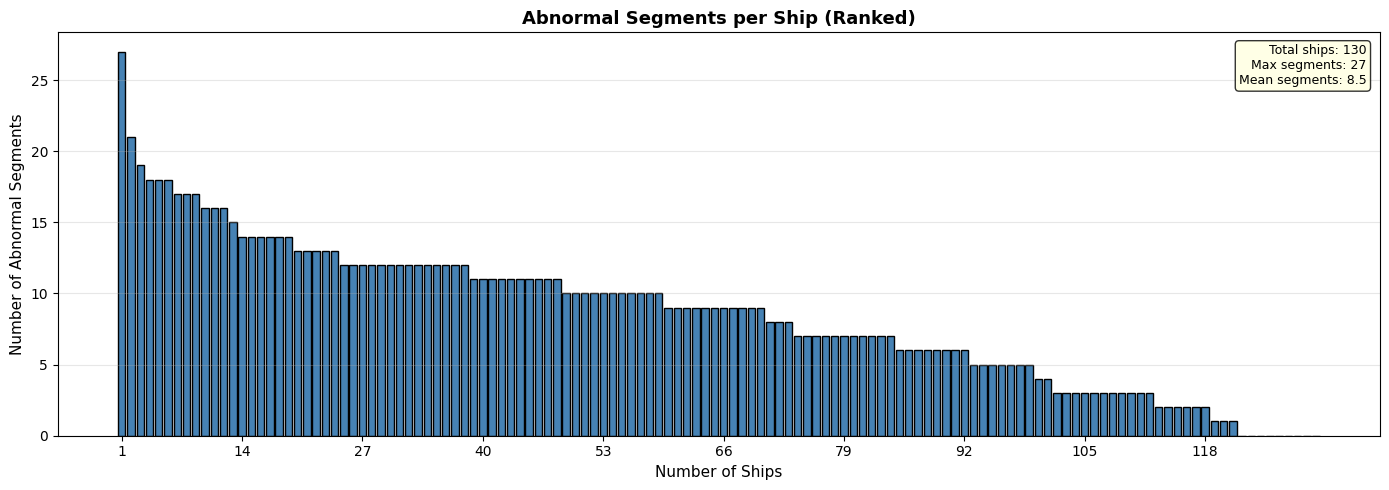

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

if len(seg_df_all) > 0:
    seg_count_df_sorted = seg_count_df.sort_values('n_segments', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.bar(range(len(seg_count_df_sorted)),
           seg_count_df_sorted['n_segments'].values,
           color='steelblue', edgecolor='k', width=0.8)

    ax.set_xlabel('Number of Ships', fontsize=11)
    ax.set_ylabel('Number of Abnormal Segments', fontsize=11)
    ax.set_title('Abnormal Segments per Ship (Ranked)', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    # X-axis: show actual ship count ticks, not indices
    tick_step = max(1, len(seg_count_df_sorted) // 10)
    ax.set_xticks(range(0, len(seg_count_df_sorted), tick_step))
    ax.set_xticklabels(range(1, len(seg_count_df_sorted)+1, tick_step))

    # Annotate total ships and max segments
    ax.text(0.99, 0.97,
            f"Total ships: {len(seg_count_df_sorted)}\n"
            f"Max segments: {seg_count_df_sorted['n_segments'].max()}\n"
            f"Mean segments: {seg_count_df_sorted['n_segments'].mean():.1f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()